In [1]:
import os
os.chdir("..")
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

In [2]:
FEATURE_COLS = ["hr", "hrv", "eda", "wrist_temp", "co2_noisy", "lux_noisy", "posture_cm"]
df = pd.read_csv("outputs/unified_features.csv").dropna(subset=FEATURE_COLS)

def is_ambiguous(row, hr_margin=5, hrv_margin=5):
    hr_close = abs(row["hr"] - 90) <= hr_margin
    hrv_close = abs(row["hrv"] - 25) <= hrv_margin
    return hr_close or hrv_close

df["is_ambiguous"] = df.apply(is_ambiguous, axis=1)
print(f"Ambiguous rows: {df['is_ambiguous'].sum()} / {len(df)} ({df['is_ambiguous'].mean()*100:.1f}%)")

Ambiguous rows: 512 / 2139 (23.9%)


In [3]:
from sklearn.model_selection import StratifiedGroupKFold

N_REPEATS = 10
cascade_f1, ml_only_f1, rule_only_f1 = [], [], []
ml_call_fraction = []

for repeat in range(N_REPEATS):
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=repeat)
    for train_idx, test_idx in sgkf.split(X, y, groups=groups):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[train_idx])
        Xte = scaler.transform(X[test_idx])
        clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
        clf.fit(Xtr, y[train_idx])

        test_df = df.iloc[test_idx].reset_index(drop=True)
        ml_preds = clf.predict(Xte)
        rule_preds = le.transform(test_df["rule_prediction_binary"])
        cascade_preds = np.where(test_df["is_ambiguous"].values, ml_preds, rule_preds)

        y_test = y[test_idx]
        cascade_f1.append(f1_score(y_test, cascade_preds, average="macro", zero_division=0))
        ml_only_f1.append(f1_score(y_test, ml_preds, average="macro", zero_division=0))
        rule_only_f1.append(f1_score(y_test, rule_preds, average="macro", zero_division=0))
        ml_call_fraction.append(test_df["is_ambiguous"].mean())

print(f"Rule-only F1: {np.mean(rule_only_f1):.4f}")
print(f"ML-only F1:   {np.mean(ml_only_f1):.4f}")
print(f"Cascade F1:   {np.mean(cascade_f1):.4f}")
print(f"ML invoked on avg: {np.mean(ml_call_fraction)*100:.1f}% of samples")
print(f"n={len(cascade_f1)} fold-scores")

NameError: name 'X' is not defined

In [4]:
results = pd.DataFrame({
    "rule_only": rule_only_f1, "ml_only": ml_only_f1, "cascade": cascade_f1
})
results.to_csv("outputs/cascade_results.csv", index=False)

print("""
Write-up angle: if cascade F1 is close to ML-only F1 but only invokes
the expensive model on a small fraction of samples, that's your claim:
'X% of the accuracy of a full ML model, at Y% of the inference cost.'
""")


Write-up angle: if cascade F1 is close to ML-only F1 but only invokes
the expensive model on a small fraction of samples, that's your claim:
'X% of the accuracy of a full ML model, at Y% of the inference cost.'



In [5]:
ambiguous_only = df[df["is_ambiguous"] == True].copy()
print(f"Testing fusion specifically on {len(ambiguous_only)} ambiguous rows")

from sklearn.model_selection import StratifiedGroupKFold

def test_on_subset(subset_df, feats, label="test"):
    X = subset_df[feats].values
    y_sub = LabelEncoder().fit_transform(subset_df["ground_truth"])
    groups_sub = subset_df["subject"].values
    if len(np.unique(y_sub)) < 2 or len(subset_df) < 20:
        print(f"{label}: not enough data/class diversity to test reliably (n={len(subset_df)})")
        return None
    sgkf = StratifiedGroupKFold(n_splits=min(5, len(np.unique(groups_sub))), shuffle=True, random_state=42)
    scaler = StandardScaler()
    scores = []
    for tr, te in sgkf.split(X, y_sub, groups=groups_sub):
        Xtr, Xte = scaler.fit_transform(X[tr]), scaler.transform(X[te])
        clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
        clf.fit(Xtr, y_sub[tr])
        scores.append(f1_score(y_sub[te], clf.predict(Xte), average="macro", zero_division=0))
    print(f"{label}: F1={np.mean(scores):.4f} (n={len(subset_df)})")
    return scores

bio_scores = test_on_subset(ambiguous_only, ["hr", "hrv", "eda", "wrist_temp"], "Biometrics-only (ambiguous subset)")
fused_scores = test_on_subset(ambiguous_only, ["hr", "hrv", "eda", "wrist_temp", "co2_noisy", "lux_noisy", "posture_cm"], "Fused (ambiguous subset)")

Testing fusion specifically on 512 ambiguous rows
Biometrics-only (ambiguous subset): F1=0.8327 (n=512)
Fused (ambiguous subset): F1=0.8043 (n=512)


C:\Anaconda\envs\journal\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Anaconda\envs\journal\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


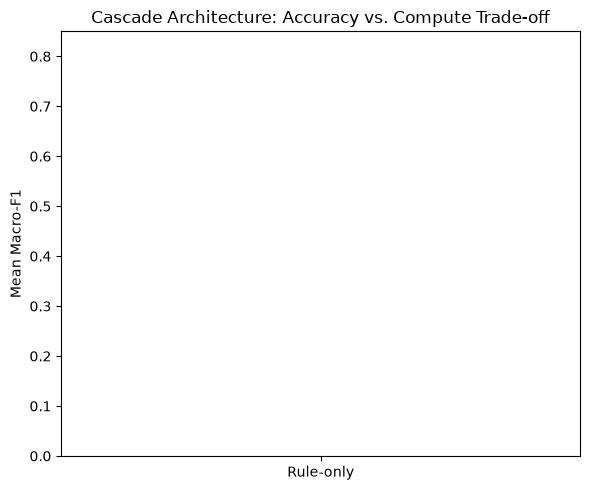

In [6]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Rule-only", "Cascade", "ML-only"]
values = [np.mean(rule_only_f1), np.mean(cascade_f1), np.mean(ml_only_f1)]
ml_pct = np.mean(ml_call_fraction) * 100

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=["#8C8C8C", "#DD8452", "#4C72B0"])
plt.ylabel("Mean Macro-F1")
plt.title("Cascade Architecture: Accuracy vs. Compute Trade-off")
plt.text(1, values[1] + 0.02, f"{ml_pct:.1f}% ML\ninvocation", ha="center", fontsize=9)
plt.ylim(0, 0.85)
plt.tight_layout()
plt.savefig("outputs/figure6_cascade_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()